In [1]:
from src.cedapp.drx import CL_FD_Update as CL
from src.cedapp.drx.pic import Pics
from src.cedapp.drx.gauge import Gauge, Element
import os
from src.cedapp.drx import Oscilloscope_LeCroy_QTinterface as Oscilo

import matplotlib.pyplot as plt
bibdrx=CL.DRX(folder=[os.path.join(r"resources/bibdrx/H2O", f) for f in os.listdir(r"resources/bibdrx/H2O")] + [os.path.join(r"resources/bibdrx/Sn", f) for f in os.listdir(r"resources/bibdrx/Sn")],E=19000)

LOADED: CL_FD_Update:2026-03-02 18:06:32
Vmin too low → reset to 0.8*V0


In [2]:
bibdrx.Bibli_elements.keys()

dict_keys(['H2O_Ice_Ic', 'H2O_Ice_Ih', 'H2O_Ice_II', 'H2O_Ice_III', 'H2O_Ice_V', 'H2O_Ice_VI', 'H2O_Ice_VII', 'H2O_Ice_XXI', 'Sn_Gamma', 'Sn_alpha', 'Sn_bcc', 'Sn_Beta'])

In [21]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import UnivariateSpline

# --- Couleurs pour les phases ---
color_set = {
    "H2O_Ice_VII": '#1f77b4',
    "H2O_Ice_VI": 'g',
    "H2O_Ice_Ih": 'r',
    "H2O_Liquid": '#2ca02c',
}

# --- Limites des phases (exemple, à adapter) ---
phase_boundaries = {
    "H2O_Ice_VII": (0, 5),
    "Sn_Beta": (0, 10),
}

list_folder = [r"f:\ESRF\2023 Mai HC-5293 id09",r"f:\ESRF\2024 Juin HC-5719 id09",r"f:\ESRF\2025 Juin HC -6205 id09",r"f:\ESRF\2026 Janvier HC-6664 id09"]
#list_folder =[r"f:\ESRF\TEST"]

In [61]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy.interpolate import UnivariateSpline

# --- Initialisation ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

def detect_h2o_phases(run):
    """Détecte uniquement les phases H2O_* à partir des colonnes P_* dans Summary."""
    phases = []
    for col in run.Summary.columns:
        if col.startswith("P_H2O_"):
            # Exemple: "P_H2O_Ice_VII" -> "H2O_Ice_VII"
            phase_name = "_".join(col.split("_")[1:])
            phases.append(phase_name)
    return phases

def extrapolate_path(x, y, method="spline"):
    """Extrapolation non linéaire du chemin (P vs t)."""
    if len(x) < 2:
        return x, y
    if method == "spline":
        spline = UnivariateSpline(x, y, s=0)
        x_extrapolated = np.linspace(min(x), max(x), 100)
        y_extrapolated = spline(x_extrapolated)
    else:
        coeffs = np.polyfit(x, y, 3)
        poly = np.poly1d(coeffs)
        x_extrapolated = np.linspace(min(x), max(x), 100)
        y_extrapolated = poly(x_extrapolated)
    return x_extrapolated, y_extrapolated

# --- Traitement des dossiers ---
for folder in list_folder:
    folder_file = os.path.join(folder, "Fichier_CED_DRX")
    print(f"Processing folder: {folder}")

    l_file = os.listdir(folder_file)
    for file_run in tqdm(l_file):
        fullpath = os.path.join(folder_file, file_run)
        if not os.path.isfile(fullpath):
            continue
        if "water" not in fullpath.lower() and "watter" not in fullpath.lower():
            continue

        try:
            run = CL.LOAD_CEDd(fullpath)  # Charger le RUN

            # --- Extraction des données ---
            t = np.array(run.Time_spectrum)
            p_dict = {}  # Dictionnaire pour stocker les pressions par phase H2O

            # --- Détection et extraction des pressions H2O ---
            h2o_phases = detect_h2o_phases(run)
            for phase in h2o_phases:
                p_col = f"P_{phase}"
                if p_col in run.Summary.columns:
                    p_dict[phase] = np.array(run.Summary[p_col])

            # --- Détection de la tendance (montée/descente) ---
            if len(p_dict) > 0:
                sample_phase = next(iter(p_dict))
                p_sample = p_dict[sample_phase]
                dpdt_sample = np.gradient(p_sample, t* 1e3 )  # dP/dt en GPa/ms

                if np.mean(dpdt_sample) > 0:
                    ax = ax2  # Côté droit (dp/dt > 0)
                    title = "Compression (dp/dt > 0)"
                else:
                    ax = ax1  # Côté gauche (dp/dt < 0)
                    title = "Décompression (dp/dt < 0)"

                # --- Tracé des phases H2O (extrapolé uniquement) ---
                for phase in h2o_phases:
                    if phase not in phase_boundaries:
                        continue

                    p = p_dict.get(phase, None)
                    if p is None:
                        continue

                    # Extrapolation de P vs t
                    t_extrapolated, p_extrapolated = extrapolate_path(t, p, method="spline")

                    # Calcul de dp/dt à partir de P extrapolé
                    dpdt_extrapolated = np.gradient(p_extrapolated, t_extrapolated) * 1e-3

                    # Tracé P vs dp/dt
                    ax.plot(dpdt_extrapolated, p_extrapolated,
                            color=color_set.get(phase, 'k'),
                            linestyle="-", alpha=0.7, label=f"{phase} (extrapolé)")

        

        except Exception as e:
            print(f"Error processing {file_run}: {e}")
            continue
        
ax.set_xlabel("dp/dt (GPa/ms)")
ax.set_ylabel("Pressure (GPa)")
ax.set_title(title)
ax.legend()

plt.tight_layout()
plt.show()

Processing folder: f:\ESRF\TEST


100%|██████████| 13/13 [00:01<00:00, 12.74it/s]


Error processing Water_02_scan31_110625_17h25: Can't get attribute 'Pics' on <module 'Bibli_python.CL_FD_Update' from 'C:\\Users\\ADM_DEMBELEF\\Documents\\GitHub\\TR-XRD-ID09\\src\\Bibli_python\\CL_FD_Update.py'>
Error processing Water_02_scan31_110625_17h25.CEDX: when 1d, distances must match the length of the corresponding dimension


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import UnivariateSpline

# --- Couleurs et marqueurs pour les phases ---
phase_style = {
    "H2O_Ice_VII": {'color': '#1f77b4', 'marker': 'o', 'label': 'H2O_Ice_VII'},
    "H2O_Ice_VI": {'color': '#2ca02c', 'marker': 's', 'label': 'H2O_Ice_VI'},
    "H2O_Ice_Ih": {'color': 'b', 'marker': '^', 'label': 'H2O_Ice_Ih'},
    "H2O_Liquid": {'color': '#ff7f0e', 'marker': '+', 'label': 'H2O_Liquid (extrapolé)'},
}

def detect_h2o_phases(run):
    """Détecte uniquement les phases H2O_* solides à partir des colonnes P_* dans Summary."""
    phases = []
    for col in run.Summary.columns:
        if col.startswith("P_H2O_"):
            phase_name = "_".join(col.split("_")[1:])
            phases.append(phase_name)
    return phases


key="d2o"# "water"


# --- Initialisation ---
fig, ax = plt.subplots(figsize=(10, 6))


# --- Traitement des dossiers ---
for folder in list_folder:
    folder_file = os.path.join(folder, "Fichier_CED_DRX")
    #print(f"Processing folder: {folder}")

    l_file = os.listdir(folder_file)
    for file_run in tqdm(l_file):
        fullpath = os.path.join(folder_file, file_run)
        if not os.path.isfile(fullpath):
            continue
        if key not in fullpath.lower():
            continue

        try:
            run = CL.LOAD_CEDd(fullpath)  # Charger le RUN
            #print(fullpath.lower() )
            t = np.array(run.Time_spectrum) * 1e3  # Conversion en ms si nécessaire
            t = t[:len(run.Summary)]  # Rogner t pour qu'il ait la même longueur que le Summary



            phase_list = detect_h2o_phases(run)

            # --- Calcul de p_mean_total (moyenne de toutes les pressions disponibles) ---
            p_mean_total = np.zeros_like(t, dtype=float)
            count_total = np.zeros_like(t, dtype=int)

            for col in run.Summary.columns:
                if col.startswith("P_"):
                    p = np.array(run.Summary[col])
                    if len(p) == len(t):
                        p_nanfree = np.where(np.isnan(p), 0, p)
                        p_mean_total += p_nanfree
                        count_total += ~np.isnan(p)

            mask_total = count_total > 0
            p_mean_total[mask_total] /= count_total[mask_total]

            # --- Interpolation de p_mean_total avec UnivariateSpline (masque NaN) ---
            valid_mask_mean = ~np.isnan(p_mean_total)
            if np.any(valid_mask_mean) and len(t[valid_mask_mean]) >= 2:
                spline_mean = UnivariateSpline(t[valid_mask_mean], p_mean_total[valid_mask_mean], s=1)
                t_fine = np.linspace(t.min(), t.max(), 200)  # Grille plus fine
                p_mean_total_interp = spline_mean(t_fine)
                dpdt_mean_total_interp = np.gradient(p_mean_total_interp, t_fine)
            else:
                print("⚠️ Aucun point valide pour p_mean_total ou trop peu de points.")
                t_fine = np.linspace(t.min(), t.max(), 200)
                p_mean_total_interp = np.full_like(t_fine, np.nan)
                dpdt_mean_total_interp = np.full_like(t_fine, np.nan)
            
            # --- Détection des temps où il n'y a AUCUNE phase solide H2O ---
            no_solid_phase_mask = np.ones(len(t), dtype=bool)
            for phase in phase_list:
                p = np.array(run.Summary[f"P_{phase}"])
                no_solid_phase_mask &= np.isnan(p)

            # --- Tracé des phases solides ---
            for phase in phase_list:
                try:
                    p = np.array(run.Summary[f"P_{phase}"])
                    valid_mask = ~np.isnan(p)
                    style = phase_style.get(phase, {'color': 'k', 'marker': 'o', 'label': phase})
                    if np.any(valid_mask) and len(t[valid_mask]) >= 2:

                        # Marquage des points réels valides
                        dpdt_real = np.gradient(p[valid_mask], t[valid_mask])
                        
                        #ax.plot(dpdt_real, p[valid_mask],c=style['color'], linestyle="-", linewidth=1.5)
                        ax.scatter(dpdt_real, p[valid_mask],
                                    c=style['color'], marker=style['marker'], s=150, alpha=0.7, label=style['label'])
                    else:
                        # Cas où on n'interpole pas : utiliser p_mean_total_interp
                        dpdt_mean_interp = np.interp(t[valid_mask], t_fine, dpdt_mean_total_interp)
                        ax.scatter(dpdt_mean_interp, p[valid_mask],
                                    c=style['color'], marker=style['marker'], s=150, alpha=0.7, label=style['label'])
                        

            
                except KeyError:
                    print(f"Phase {phase} non trouvée dans les colonnes du Summary.")
        except Exception as e:
            print(f"Error processing {file_run}: {e}")
            continue
# --- Apparence du graphique ---
ax.set_xlabel("dp/dt (GPa/ms)")
ax.set_ylabel("Pressure (GPa)")
#ax.legend()
#ax.grid(True)

# Domaines de phase de l'eau (en GPa)
phase_ranges = {
    "Liquid": (0, 0.97),
    "Ice VI": (0.97, 2.067),
    "Ice VII": (2.067, 10),  # Arbitraire pour le haut de l'échelle
}

# Couleurs pour les bandes
phase_colors = {
    "Liquid": '#ff7f0e',  # Bleu clair pour le liquide
    "Ice VI": '#2ca02c',  # Vert clair pour Ice VI
    "Ice VII": '#1f77b4',  # Bleu très clair pour Ice VII
}

# Ajout des bandes hspan pour chaque domaine de phase
for phase_name, (p_min, p_max) in phase_ranges.items():
    ax.axhspan(p_min, p_max, color=phase_colors[phase_name], alpha=0.1)
    # Ajouter une légende pour les bandes
    ax.axhspan(p_min, p_max, color=phase_colors[phase_name], alpha=0.1)
# Créer une échelle symlog manuellement
ax.set_xscale('symlog',linthresh=1e-2, linscale=1e-2)
ax.set_ylim(0,8)

from matplotlib.ticker import LogLocator, SymmetricalLogLocator

# --- Configuration de la grille ---
ax.grid(which="both", axis="x", linestyle='-', alpha=0.9)  # Grille principale en trait plein
ax.grid(which="minor", axis="x", linestyle=':', alpha=0.6)  # Grille secondaire en pointillés

# --- Configurer les locators pour la grille ---
if 'symlog' in ax.get_xscale():
    # Pour une échelle symlog
    ax.xaxis.set_major_locator(SymmetricalLogLocator(linthresh=0.1, subs=[1.0], base=10))
    ax.xaxis.set_minor_locator(SymmetricalLogLocator(linthresh=0.1, subs=np.arange(2, 10), base=10))
else:
    # Pour une échelle log classique
    ax.xaxis.set_major_locator(LogLocator(subs=[1.0], numticks=10))
    ax.xaxis.set_minor_locator(LogLocator(subs=np.arange(2, 10), numticks=10))
plt.tight_layout()
plt.show()

  0%|          | 0/144 [00:00<?, ?it/s]

 17%|█▋        | 25/144 [00:18<01:28,  1.34it/s]

Error processing D2O_02_scan0032.CEDX: (m>k) failed for hidden m: fpcurf0:m=3


 19%|█▉        | 27/144 [00:20<01:53,  1.03it/s]

Error processing D2O_02_scan0037.CEDX: (m>k) failed for hidden m: fpcurf0:m=2


ERROR:pyFAI.geometry.core:Unable to initialize geometry from None
 30%|██▉       | 43/144 [00:27<00:26,  3.77it/s]

⚠️ Aucun point valide pour p_mean_total ou trop peu de points.
Error processing D2O_04_scan0011.CEDX: zero-size array to reduction operation minimum which has no identity
⚠️ Aucun point valide pour p_mean_total ou trop peu de points.
Error processing D2O_04_scan0012.CEDX: zero-size array to reduction operation minimum which has no identity


100%|██████████| 144/144 [00:29<00:00,  4.85it/s]


In [4]:

fullpath=r"f:\Aquisition_Banc_CEDd\Fichier_CEDd\D2O_Ru2_20e6_2_170326_12h11.CEDUp"
# --- Initialisation ---
fig, ax = plt.subplots(figsize=(10, 6))


run = CL.LOAD_CEDd(fullpath)


if run is CL.CED_DRX:
    phase_list = detect_h2o_phases(run)

    # --- Calcul de p_mean_total (moyenne de toutes les pressions disponibles) ---
    p_mean_total = np.zeros_like(t, dtype=float)
    count_total = np.zeros_like(t, dtype=int)

    for col in run.Summary.columns:
        if col.startswith("P_"):
            p = np.array(run.Summary[col])
            if len(p) == len(t):
                p_nanfree = np.where(np.isnan(p), 0, p)
                p_mean_total += p_nanfree
                count_total += ~np.isnan(p)

    mask_total = count_total > 0
    p_mean_total[mask_total] /= count_total[mask_total]

    # --- Interpolation de p_mean_total avec UnivariateSpline (masque NaN) ---
    valid_mask_mean = ~np.isnan(p_mean_total)
    if np.any(valid_mask_mean) and len(t[valid_mask_mean]) >= 2:
        spline_mean = UnivariateSpline(t[valid_mask_mean], p_mean_total[valid_mask_mean], s=1)
        t_fine = np.linspace(t.min(), t.max(), 200)  # Grille plus fine
        p_mean_total_interp = spline_mean(t_fine)
        dpdt_mean_total_interp = np.gradient(p_mean_total_interp, t_fine)
    else:
        print("⚠️ Aucun point valide pour p_mean_total ou trop peu de points.")
        t_fine = np.linspace(t.min(), t.max(), 200)
        p_mean_total_interp = np.full_like(t_fine, np.nan)
        dpdt_mean_total_interp = np.full_like(t_fine, np.nan)

    # --- Détection des temps où il n'y a AUCUNE phase solide H2O ---
    no_solid_phase_mask = np.ones(len(t), dtype=bool)
    for phase in phase_list:
        p = np.array(run.Summary[f"P_{phase}"])
        no_solid_phase_mask &= np.isnan(p)

    # --- Tracé des phases solides ---
    for phase in phase_list:
        p = np.array(run.Summary[f"P_{phase}"])
        valid_mask = ~np.isnan(p)
        style = phase_style.get(phase, {'color': 'k', 'marker': 'o', 'label': phase})
        if np.any(valid_mask) and len(t[valid_mask]) >= 2:

            # Marquage des points réels valides
            dpdt_real = np.gradient(p[valid_mask], t[valid_mask])
            
            #ax.plot(dpdt_real, p[valid_mask],c=style['color'], linestyle="-", linewidth=1.5)
            ax.scatter(dpdt_real, p[valid_mask],
                        c=style['color'], marker=style['marker'], s=150, alpha=0.7, label=style['label'])
        else:
            # Cas où on n'interpole pas : utiliser p_mean_total_interp
            dpdt_mean_interp = np.interp(t[valid_mask], t_fine, dpdt_mean_total_interp)
            ax.scatter(dpdt_mean_interp, p[valid_mask],
                        c=style['color'], marker=style['marker'], s=150, alpha=0.7, label=style['label'])

elif run is CL.CED:
    dic_zone = run.phase_tracks
    element = "H2O"  # ou l'élément que tu utilises
    zones = dic_zone.get(element, [])

    for zone in zones:
        start, end = zone['start'], zone['end']

        # 1. Extraire les données pour cette zone
        mask = (t >= start) & (t <= end)
        t_zone = t[mask]
        p_zone = p_mean_total[mask]  # ou run.Summary[f"P_{zone['name']}"][mask] si disponible

        # 2. Calculer dp/dt pour cette zone
        if len(t_zone) > 0 and len(p_zone) > 0:
            dpdt_zone = np.gradient(p_zone, t_zone)

            # 3. Récupérer la couleur associée à la phase
            style = phase_style.get(phase, {'color': 'k', 'marker': 'o', 'label': phase})

            # 4. Tracer les points (P, dp/dt)
            ax.scatter(
                dpdt_zone, p_zone,
                c=style['color'], marker=style['marker'], s=150, alpha=0.7, label=style['label'])


plt.show()

AttributeError: Can't get attribute 'Pics' on <module 'Bibli_python.CL_FD_Update' from 'C:\\Users\\ADM_DEMBELEF\\Documents\\GitHub\\TR-XRD-ID09\\src\\Bibli_python\\CL_FD_Update.py'>

In [52]:
import pandas as pd

# Charger le fichier CSV
df = pd.read_csv(r"f:\ESRF\Analyse\D2O_Liquid_to_D2O_Ice_VII.csv", sep=';')  # ou sep=',' selon ton séparateur

# Afficher les premières lignes pour vérifier
print(df.keys())

Index(['transition', 'file', 'P_VI (GPa)', 'sigP_VI  (GPa)', 't_lim_VI  (ms)',
       't_start_transition_VI  (ms)', 'dt_VI  (ms)', 'digdt_VI ',
       'dP/dt_VI  (Gpa.ms-1)', 'sigdP/dt_VI ', 't_end_transition_VI ',
       't_tot_trans_VI ', 'P_end_transition_VI ', 'ice VII', 'P_VII (GPa)',
       'sigP_VII  (GPa)', 't_lim_VII  (ms)', 't_start_transition_VII  (ms)',
       'dt_VII  (ms)', 'digdt_VII ', 'dP/dt_VII  (Gpa.ms-1)', 'sigdP/dt_VII ',
       't_end_transition_VII ', 't_tot_trans_VII ', 'P_end_transition_VII ',
       'com'],
      dtype='object')


In [54]:
import matplotlib.pyplot as plt

fig,ax =plt.subplots()

# --- Tracer les points de transition Ice VI ---
if 'P_VI (GPa)' in df.columns:
    ax.scatter(df['dP/dt_VI  (Gpa.ms-1)'], df['P_VI (GPa)'],
               c='g', marker='s', s=100, label='Transition Ice VI', alpha=0.7)

# --- Tracer les points de transition Ice VII ---
if 'P_VII (GPa)' in df.columns:
    ax.scatter(df['dP/dt_VII  (Gpa.ms-1)'], df['P_VII (GPa)'],
               c='b', marker='s', s=100, label='Transition Ice VI', alpha=0.7)


plt.show()

In [78]:
a=np.array([1,2,3])+np.array([np.nan,2,3])
print(a)

[nan  4.  6.]


In [48]:
run.Summary

,n°Spec,a_H2O_Ice_VII,b_H2O_Ice_VII,c_H2O_Ice_VII,c/a_H2O_Ice_VII,V_H2O_Ice_VII,P_H2O_Ice_VII,a_H2O_Ice_VI,b_H2O_Ice_VI,c_H2O_Ice_VI,c/a_H2O_Ice_VI,V_H2O_Ice_VI,P_H2O_Ice_VI
0,0,3.235,3.235,3.235,1.0,33.855,5.762,NaN,NaN,NaN,NaN,NaN,NaN
1,1,3.243,3.243,3.243,1.0,34.107,5.460,NaN,NaN,NaN,NaN,NaN,NaN
2,2,3.262,3.262,3.262,1.0,34.710,4.776,NaN,NaN,NaN,NaN,NaN,NaN
3,3,3.293,3.293,3.293,1.0,35.709,3.754,NaN,NaN,NaN,NaN,NaN,NaN
4,4,3.350,3.350,3.350,1.0,37.595,2.146,NaN,NaN,NaN,NaN,NaN,NaN
5,5,NaN,NaN,NaN,NaN,NaN,NaN,6.219,6.219,5.714,0.918797,220.994,0.44


In [ ]:
file=r"d:\ESRF\2024 Juin HC-5719 id09\Fichier_CED_DRX\ESRFid09_2024_Water10_run24.CEDXUp"
ced=CL.LOAD_CEDd(file)
#bibdrx=CL.DRX(folder=[r"resources/bibdrx/H2O/Ice-Ih.jcpds", r"resources/bibdrx/H2O/Ice-VI.jcpds", r"resources/bibdrx/H2O/Ice-VII.jcpds", r"C:/Users/ADM_DEMBELEF/Documents/GitHub/DRX/BibDRX/Sn/Sn_Beta_modif.jcpds"],E=19000)

In [13]:
for line in ced.Spectra[0].Gauges[0].Element_ref.Dhkl.:
    print(line)

Dhkl
I
h
k
l


In [22]:
self.Dhkl=ced.Spectra[0].Gauges[0].Element_ref.Dhkl

In [30]:
name_dhkl=[]
for i in range(len(self.Dhkl)):
    name_dhkl.append((int(self.Dhkl.h[i]),int(self.Dhkl.k[i]),int(self.Dhkl.l[i])))
print(name_dhkl)

[(2, 0, 0), (1, 0, 1), (2, 2, 0), (2, 1, 1), (3, 0, 1), (1, 1, 2), (4, 0, 0), (3, 2, 1), (4, 2, 0), (4, 1, 1), (3, 1, 2), (5, 0, 1), (3, 3, 2), (5, 2, 1), (2, 1, 3), (6, 0, 0), (3, 0, 3), (5, 1, 2), (6, 2, 0), (6, 1, 1), (3, 2, 3), (5, 4, 1), (4, 1, 3), (5, 3, 2), (6, 3, 1), (6, 4, 0), (7, 0, 1), (0, 0, 4), (5, 0, 3), (7, 2, 1), (2, 0, 4), (5, 2, 3), (2, 2, 4), (7, 1, 2), (8, 0, 0), (6, 5, 1), (6, 1, 3), (8, 2, 0), (8, 1, 1), (4, 0, 4), (5, 4, 3), (7, 3, 2), (6, 6, 0), (4, 2, 4), (6, 3, 3), (8, 3, 1), (7, 0, 3), (8, 4, 0), (7, 2, 3), (9, 0, 1), (1, 0, 5), (4, 4, 4), (7, 5, 2), (9, 2, 1), (2, 1, 5), (6, 0, 4), (6, 5, 3), (8, 5, 1), (3, 0, 5), (6, 2, 4), (8, 1, 3), (9, 1, 2), (3, 2, 5), (10, 0, 0), (9, 4, 1), (4, 1, 5), (8, 3, 3), (9, 3, 2), (10, 2, 0), (10, 1, 1), (6, 4, 4), (5, 0, 5), (9, 0, 3), (7, 7, 2), (10, 3, 1), (5, 2, 5), (9, 2, 3), (10, 4, 0), (8, 7, 1), (8, 0, 4), (8, 5, 3), (9, 5, 2), (9, 6, 1), (6, 1, 5), (8, 2, 4), (1, 1, 6), (11, 0, 1), (5, 4, 5), (6, 6, 4), (9, 4, 3), (8,

In [21]:
1/((t[10]-t[0])/10) 

np.float64(5.000000000000071)

In [14]:
import numpy as np
errs=[1.0]
if errs is not None and np.all(np.array(errs) < 0.5):
    print("yes",np.all(np.array(errs) < 0.5))

In [4]:
import copy
import numpy as np
nb=9
X = ced.Spectra[nb]
height=0.04
distance=1
prominence=0.07
width=4.3
number_peak_max=10
nb_max_element=3
last_pressure=1.2
index_start=8


theta2_range=[[11,22]]
# Détection des pics
x=X.wnb
y=copy.deepcopy(X.y_corr)
y_mask = []
last_valid = None
for yi, xi in zip(y, x):
    if any(a <= xi <= b for a, b in theta2_range):
        last_valid = yi
        y_mask.append(yi)
    else:
        y_mask.append(last_valid if last_valid is not None else 0)
_, detected_peaks, result = bibdrx.F_Find_peaks(
                X.wnb, y_mask,
                height=height*max(y_mask),
                distance=distance,
                prominence=prominence*max(y_mask),
                width=width,
                number_peak_max=number_peak_max
            )
print(f"[DRX {nb}] Peaks found: {[f'th2:{pic} I:{i}' for pic,i in zip(detected_peaks,result['peak_heights'])]}")






best_ind, _, Gauges = bibdrx.F_Find_compo(
    detected_peaks,
    NGEN=100,
    MUTPB=0.5,
    CXPB=0.5,
    POPINIT=100,
    pressure_range=[-0.5, 15] if nb == index_start else[last_pressure * 0.75 - 2, last_pressure * 1.25 + 2],
    max_ecart_pressure=2,
    max_elements=nb_max_element,
    theta2_range=theta2_range,
    tolerance=0.1,
    indiv_start=best_ind,
    print_process=True
)
# Mise à jour du spectre
X.Gauges = Gauges
X.bit_fit = True
for x,g in enumerate(X.Gauges):
    pi=0
    for ps,save in enumerate(g.Element_ref.save_var):
        if save:
            x0=g.Element_ref.thetas_PV[ps][0]
            m=np.argmin(np.abs(X.wnb -x0 ))
            g.pics[pi].ampH[0]=round(X.y_corr[m],3)
            g.pics[pi].Update()
            pi+=1
    g.Update_model()
    g.bit_fit=True
X.Calcul_study(mini=True)

[DRX 9] Peaks found: ['th2:17.43578555273579 I:332.8565368652344', 'th2:18.770756528727983 I:208.0716552734375', 'th2:14.560463450598752 I:124.89755249023438', 'th2:13.815960406295408 I:233.43228149414062', 'th2:15.176603901056689 I:57.824005126953125', 'th2:18.385668747191772 I:328.0472412109375', 'th2:12.917422249377584 I:300.5936279296875']
Génération 0: Meilleur score = 55.76433188633298, Individu = [(np.str_('H2O_Ice_VI'), 0.5)]
Génération 10: Meilleur score = 13.603270146308104, Individu = [(np.str_('H2O_Ice_VI'), 1.1), (np.str_('Sn_Beta'), np.float64(1.1))]
Génération 20: Meilleur score = 13.603270146308104, Individu = [(np.str_('H2O_Ice_VI'), 1.1), (np.str_('Sn_Beta'), np.float64(1.1))]
 Dhkl ref refresh :  ; D201 ; D102 ; D211 ; D220
 Dhkl ref refresh :  ; D200 ; D220 ; D211
Compo found at Génération 24 after 20 static généneration: Meilleur score = 13.603270146308104, 
 Individu = [(np.str_('H2O_Ice_VI'), 1.1), (np.str_('Sn_Beta'), np.float64(1.1))]
- - - - - - CALCUL H2O_Ice

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import re
import numpy as np

In [4]:
#DATA 2023
import os, re
from collections import defaultdict
clear_and_stand=False
d_start_oscilo = r'D:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023'
d_start_drx    = r"D:\ESRF\2023 Mai HC-5293 id09\PROCESSED_DATA"

import re
import pandas as pd

def format_file(file):
    # Lire et stocker le contenu original
    with open(file, "r", encoding="utf-8", errors="ignore") as f:
        original_content = f.read()
    # Faire une copie nettoyée en mémoire (sans écraser)
    content_clean = original_content.replace(",", ".")

    lines = content_clean.splitlines()

    # 1) Retirer les lignes parasites 8f / 8f.x
    kept = []
    for line in lines:
        # supprimer les \n et espaces
        stripped = line.strip()
        if not stripped:   # saute les lignes vides
            continue

        tokens = re.split(r'[\t ]+', stripped)
        # saute les lignes "8f", "8f.1", ...
        if tokens and all(re.match(r'^8f(\.\d+)?$', tok, re.IGNORECASE) for tok in tokens):
            continue

        kept.append(line)  # garde la ligne originale (avec son \n)

    if not kept:
        raise ValueError("Fichier vide après suppression des lignes '8f'.")

    kept[0]="Time	Channel1	Channel2	Channel3	Channel4"

    with open(file, "w", encoding="utf-8") as f:
        f.write("\n".join(kept))



# --- 1) Construire l'index DRX : drx_index[water][run] -> liste .npy triée ---
drx_index = defaultdict(lambda: defaultdict(list))

# Trouver tous les dossiers Water_* dans PROCESSED_DATA
for dos in os.listdir(d_start_drx):
    mW = re.search(r'water[_\s]*0*([0-9]+)$', dos, flags=re.IGNORECASE)
    if not mW:
        continue
    wnum = int(mW.group(1))
    path_water = os.path.join(d_start_drx, dos)
    if not os.path.isdir(path_water):
        continue

    # Lister les .npy et les ranger par run
    for f in os.listdir(path_water):
        if not f.lower().endswith('.npy'):
            continue
        m_run = re.search(r'run0*([0-9]+)', f, flags=re.IGNORECASE)
        if not m_run:
            continue
        run_num = int(m_run.group(1))
        full_path = os.path.join(path_water, f)
        drx_index[wnum][run_num].append(full_path)

    # Trier chaque liste par l'index numérique final (…_<idx>.npy)
    for run_num in drx_index[wnum]:
        drx_index[wnum][run_num].sort(
            key=lambda x: int(re.search(r'_(\d+)\.npy$', x).group(1)) if re.search(r'_(\d+)\.npy$', x) else -1
        )

# --- 2) Parcourir les dossiers oscillo et remplir l_concat ---
l_concat = []   # chaque entrée: [[nom_oscillo, [liste .npy du run]], ...]
l_cle    = []   # infos (water_num, run_num) par fichier oscillo (optionnel)

for dos in [file for file in os.listdir(d_start_oscilo) if "WATER" in file.upper()]:
    # Numéro de WATER depuis le nom du dossier oscillo
    m = re.search(r'WATER[_\s]*0*([0-9]+)', dos, flags=re.IGNORECASE)
    wnum = int(m.group(1)) if m else None

    contenu_oscilo  = os.listdir(os.path.join(d_start_oscilo, dos))
    # Pour chaque fichier oscillo, extraire (water?, run?) et associer la liste .npy
    bloc = []
    bloc_cle = []
    for cont in contenu_oscilo:
        # Numéro RUN dans le nom du fichier oscillo
        m_run = re.search(r'run[_\s]*0*([0-9]+)', cont, flags=re.IGNORECASE)
        run_num = int(m_run.group(1)) if m_run else None

        # Chercher la liste .npy correspondante dans l'index DRX
        files_npy = []
        if wnum is not None and run_num is not None:
            files_npy = drx_index.get(wnum, {}).get(run_num, [])
        # Ajoute [nom_oscillo, liste_npy_du_run]
        if clear_and_stand:
            format_file(os.path.join(os.path.join(d_start_oscilo, dos),cont)) 
        bloc.append([os.path.join(os.path.join(d_start_oscilo, dos),cont), files_npy])
        # (optionnel) garde la clé info (water, run) pour ce fichier
        bloc_cle.append((wnum, run_num))

    l_concat.append(bloc)
    l_cle.append(bloc_cle)

# ====== Exemples d'accès ======
# l_concat[k]  -> la k-ième liste (dossier oscillo)
# l_concat[k][i] -> [nom_oscillo, liste_npy]
# l_cle[k][i]    -> (water_num, run_num) correspondant

# Exemple: afficher un aperçu
for k, bloc in enumerate(l_concat):  # deux premiers dossiers
    print(f"\nDossier oscillo #{k}:")
    for nom_osc, npys in bloc[:3]:       # trois premiers fichiers
        print("  -", nom_osc, "→", (len(npys), "fichiers .npy"))



Dossier oscillo #0:
  - D:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023\WATER02_17MAI 2023\Water_O2 Run 05 → (16, 'fichiers .npy')
  - D:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023\WATER02_17MAI 2023\Water_O2 Run 07 → (16, 'fichiers .npy')
  - D:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023\WATER02_17MAI 2023\Water_O2 Run 09 → (16, 'fichiers .npy')

Dossier oscillo #1:
  - D:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023\WATER03_17MAI 2023\Water_O3 Run 02 → (16, 'fichiers .npy')
  - D:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023\WATER03_17MAI 2023\Water_O3 Run 03 → (16, 'fichiers .npy')
  - D:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023\WATER03_17MAI 2023\Water_O3 Run 04 → (16, 'fichiers .npy')

Dossier oscillo #2:
  - D:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023\WATER04_17MAI2023\Water_O4 Run 06 → (16, 'fichiers .npy')

Dossier oscil

In [3]:
#DATA 2024
import os, re
from collections import defaultdict
clear_and_stand=False
d_start_oscilo = r'D:\ESRF\2024 Juin HC-5719 id09\Oscillo'
d_start_drx    = r"D:\ESRF\2024 Juin HC-5719 id09\PROCESSED_DATA"

import re
import pandas as pd

def format_file(file):
    # Lire et stocker le contenu original
    with open(file, "r", encoding="utf-8", errors="ignore") as f:
        original_content = f.read()
    # Faire une copie nettoyée en mémoire (sans écraser)
    content_clean = original_content.replace(",", ".")

    lines = content_clean.splitlines()

    # 1) Retirer les lignes parasites 8f / 8f.x
    kept = []
    for line in lines:
        # supprimer les \n et espaces
        stripped = line.strip()
        if not stripped:   # saute les lignes vides
            continue

        tokens = re.split(r'[\t ]+', stripped)
        # saute les lignes "8f", "8f.1", ...
        if tokens and all(re.match(r'^8f(\.\d+)?$', tok, re.IGNORECASE) for tok in tokens):
            continue

        kept.append(line)  # garde la ligne originale (avec son \n)

    if not kept:
        raise ValueError("Fichier vide après suppression des lignes '8f'.")

    kept[0]="Time	Channel1	Channel2	Channel3	Channel4"

    with open(file, "w", encoding="utf-8") as f:
        f.write("\n".join(kept))



# --- 1) Construire l'index DRX : drx_index[water][run] -> liste .npy triée ---
drx_index = defaultdict(lambda: defaultdict(list))

# Trouver tous les dossiers Water_* dans PROCESSED_DATA
for dos in os.listdir(d_start_drx):
    mW = re.search(r'Water[_\s]*0*([0-9]+)$', dos, flags=re.IGNORECASE)
    
    if not mW:
        continue
    wnum = int(mW.group(1))
    path_water = os.path.join(d_start_drx, dos)
    if not os.path.isdir(path_water):
        continue

    # Lister les .npy et les ranger par run
    for f in os.listdir(path_water):
        if not f.lower().endswith('.npy'):
            continue
        m_run = re.search(r'run0*([0-9]+)', f, flags=re.IGNORECASE)
        if not m_run:
            continue
        run_num = int(m_run.group(1))
        full_path = os.path.join(path_water, f)
        drx_index[wnum][run_num].append(full_path)

    # Trier chaque liste par l'index numérique final (…_<idx>.npy)
    for run_num in drx_index[wnum]:
        drx_index[wnum][run_num].sort(
            key=lambda x: int(re.search(r'_(\d+)\.npy$', x).group(1)) if re.search(r'_(\d+)\.npy$', x) else -1
        )

# --- 2) Parcourir les dossiers oscillo et remplir l_concat ---
l_concat = [[] for _ in range(len(drx_index))]   # chaque entrée: [[nom_oscillo, [liste .npy du run]], ...]
l_cle    = [[] for _ in range(len(drx_index))]   # infos (water_num, run_num) par fichier oscillo (optionnel)

for file in [file for file in os.listdir(d_start_oscilo) if "WATTER" in file.upper()]:
    # Numéro de WATER depuis le nom du dossier oscillo
    m = re.search(r'Watter[_\s]*0*([0-9]+)', file, flags=re.IGNORECASE)
    wnum = int(m.group(1)) if m else None

    file_oscilo  = os.path.join(d_start_oscilo, file)


    # Numéro RUN dans le nom du fichier oscillo
    m_run = re.search(r'run[_\s]*0*([0-9]+)', file, flags=re.IGNORECASE)
    run_num = int(m_run.group(1)) if m_run else None
    # Chercher la liste .npy correspondante dans l'index DRX
    files_npy = []
    if wnum is not None and run_num is not None:
        files_npy = drx_index.get(wnum, {}).get(run_num, [])
    # Ajoute [nom_oscillo, liste_npy_du_run]

    l_concat[wnum-1].append([file_oscilo,files_npy])
    l_cle[wnum-1].append((wnum, run_num))




# ====== Exemples d'accès ======
# l_concat[k]  -> la k-ième liste (dossier oscillo)
# l_concat[k][i] -> [nom_oscillo, liste_npy]
# l_cle[k][i]    -> (water_num, run_num) correspondant

# Exemple: afficher un aperçu
for k, bloc in enumerate(l_concat):  # deux premiers dossiers
    print(f"\nDossier oscillo #{k}:")
    for nom_osc, npys in bloc:       # trois premiers fichiers
        print("  -", nom_osc, "→", (len(npys), "fichiers .npy"))


Dossier oscillo #0:
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run001_m_060624_14h27 → (16, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run004_060624_14h34 → (16, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run009_060624_14h45 → (16, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run011_060624_14h48 → (16, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run013_060624_14h53 → (16, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run015_060624_15h00 → (16, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run018_060624_15h28 → (0, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run020_060624_15h29 → (16, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run022_060624_15h37 → (16, 'fichiers .npy')
  - D:\ESRF\2024 Juin HC-5719 id09\Oscillo\Watter_01_run026_060624_16h03 → (16, 'fichiers .npy')
  - D:\E

In [4]:
print(l_concat[2][-1][1][5])
print(l_cle[3])


D:\ESRF\2024 Juin HC-5719 id09\PROCESSED_DATA\Water_03\run0012_sc_10_00us_15_00us_5.npy
[(4, 1), (4, 4), (4, 6), (4, 8), (4, 12)]


In [12]:
#2023
file_mask=r"d:\ESRF\2023 Mai HC-5293 id09\dioptas_files\CeO2.mask" 
file_poni=r"d:\ESRF\2023 Mai HC-5293 id09\dioptas_files\calib_LaB6_3_21052023.poni"
calib=Calibration.Calib_DRX(file_mask=file_mask,file_poni=file_poni,theta_range=[8,30])


In [4]:
#2024
file_poni=r"d:\ESRF\2024 Juin HC-5719 id09\Dioptas_file\calibration_LaB6_3.poni"
file_mask=r"d:\ESRF\2024 Juin HC-5719 id09\Dioptas_file\id09_bis.mask"
calib=Calibration.Calib_DRX(file_mask=file_mask,file_poni=file_poni,theta_range=[8,27.5])

In [5]:
idx_sample=16
idx_run=1
for i,run in enumerate(l_concat[idx_sample]):
    print("idx i=",i,os.path.basename(run[0]))


idx i= 0 Watter_17_run002_SCLK20_090624_18h10
idx i= 1 Watter_17_run005_SCLK20_090624_18h11
idx i= 2 Watter_17_run008_SCLK20_090624_18h23
idx i= 3 Watter_17_run010_SCLK20_090624_18h23
idx i= 4 Watter_17_run014_SCLK8_090624_18h49
idx i= 5 Watter_17_run016_SCLK8_090624_18h50
idx i= 6 Watter_17_run018_SCLK8_090624_18h59
idx i= 7 Watter_17_run020_SCLK8_090624_19h01
idx i= 8 Watter_17_run025_SCLK8_090624_19h03
idx i= 9 Watter_17_run02_SCLK8_090624_19h03


In [9]:
nb_frame=0
#testcalibration
import fabio
from matplotlib.colors import LogNorm
from scipy.signal import savgol_filter
img=np.flip(fabio.open(l_concat[idx_sample][idx_run][1][nb_frame]).data,axis=0)
#img=fabio.open(l_concat[2][-1][1][5]).data

#--- paramètres du cake ---
n_radial = 360*4      # nb points en 2θ (ou q)
n_azim   = 360*4    # nb pas en χ
unit     = "2th_deg"  # "2th_deg", "q_A^-1", "r_mm"...

# Plages optionnelles (None = auto)
radial_range   = None            # ex: (2.0, 25.0) en degrés 2θ si unit="2th_deg"
azimuth_range  = (-180, 180)     # χ en degrés

# --- intégration 2D (cake) ---
I, tth, chi = calib.ai.integrate2d(
    img, npt_rad=n_radial, npt_azim=n_azim,
    unit=unit,
    radial_range=radial_range,
    azimuth_range=azimuth_range,
    mask=calib.mask,
    method="bbox"     # rapide et fiable; "csr" pour grandes images
)

# I a la shape (n_azim, n_radial)
# tth (longueur n_radial), chi (longueur n_azim)

# --- affichage ---
fig, (ax,ax2) = plt.subplots(nrows=2,figsize=(10, 6))
# mesh non uniforme -> pcolormesh
TT, CHI = np.meshgrid(tth, chi)  # X=2θ, Y=χ
pcm = ax.pcolormesh(TT, CHI, I, shading="auto",norm=LogNorm(vmin=I[I>0].min(), vmax=I.max()))

cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label("Intensity (a.u.)")
ax.set_xlabel("2θ (deg)")
ax.set_ylabel("χ (deg)")
ax.set_title("{} \n Cake ({} × {} bins)".format(l_concat[idx_sample][idx_run][0],n_radial, n_azim))
ax.set_ylim(azimuth_range)  # garde -180..180
ax.set_aspect("auto")

nb_point=1000
tth1d, I_1D = calib.ai.integrate1d(
            img,
            nb_point,
            mask=calib.mask,
            unit="2th_deg"
        )

ax2.plot(tth1d,I_1D, color="k")
ax2.plot(tth1d, savgol_filter(I_1D,9,2),"+m")
ax2.set_xlabel("2θ (deg)")
ax2.set_ylabel("Integrated intensity (a.u.)")
ax2.set_title("Azimuthally integrated pattern")

plt.tight_layout()

plt.show()


In [49]:
sample,run=l_cle[idx_sample][idx_run]
ced=CL.CED_DRX(data_drx=l_concat[idx_sample][idx_run][1],data_oscillo=l_concat[idx_sample][idx_run][0],time_index="Channel2",calib=calib,E=19e3,flip_axis=0)
ced.CEDd_path=os.path.join(r"D:\ESRF\2024 Juin HC-5719 id09\Fichier_CED_DRX",os.path.basename("Water{}_run{}".format(sample,run))+"_ESRF2024.CEDXUp")
CL.SAVE_CEDd(ced)

Oscillo DONE


In [53]:
ced.Spectra[0].Print()

c:\Users\ADM_DEMBELEF\Documents\GitHub\DRX\Bibli_python\CL_FD_Update.py:966: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc="best")


In [6]:
for j,lrun in enumerate(l_concat):
    for i,l in enumerate(lrun):
        if l[1]!= []:
            sample,run=l_cle[j][i]
            ced=CL.CED_DRX(data_drx=l[1],data_oscillo=l[0],time_index="Channel2",calib=calib,E=19e3,flip_axis=0)
            ced.CEDd_path=os.path.join(r"D:\ESRF\2024 Juin HC-5719 id09\Fichier_CED_DRX","ESRFid09_2024_"+os.path.basename("Water{}_run{}".format(sample,run))+".CEDXUp")
            CL.SAVE_CEDd(ced)
            print(os.path.basename(l[0]),'DONE')
#os.path.basename(l_concat[0][0][0])

Oscillo DONE nb time: 16
Watter_01_run001_m_060624_14h27 DONE
Oscillo DONE nb time: 16
Watter_01_run004_060624_14h34 DONE
Oscillo DONE nb time: 16
Watter_01_run009_060624_14h45 DONE
Oscillo DONE nb time: 16
Watter_01_run011_060624_14h48 DONE
Oscillo DONE nb time: 16
Watter_01_run013_060624_14h53 DONE
Oscillo DONE nb time: 16
Watter_01_run015_060624_15h00 DONE
Oscillo DONE nb time: 16
Watter_01_run020_060624_15h29 DONE
Oscillo DONE nb time: 16
Watter_01_run022_060624_15h37 DONE
Oscillo DONE nb time: 16
Watter_01_run026_060624_16h03 DONE
Oscillo DONE nb time: 16
Watter_01_run030_060624_16h14 DONE
Oscillo DONE nb time: 16
Watter_01_run032_060624_16h15 DONE
Oscillo DONE nb time: 16
Watter_02_run0012_060624_16h57 DONE
Oscillo DONE nb time: 16
Watter_02_run002_060624_16h42 DONE
Oscillo DONE nb time: 16
Watter_02_run004_060624_16h46 DONE
Oscillo DONE nb time: 16
Watter_03_run002_060624_17h20 DONE
Oscillo DONE nb time: 16
Watter_03_run005_060624_17h54 DONE
Oscillo DONE nb time: 16
Watter_03_ru

In [110]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm 


list_folder= [r"f:\ESRF\2023 Mai HC-5293 id09",r"f:\ESRF\2024 Juin HC-5719 id09",r"f:\ESRF\2025 Juin HC -6205 id09",r"f:\ESRF\2026 Janvier HC-6664 id09"]


df_trans_VII_to_VI = []
df_last_VI = []
df_last_VII_noVI = []

all_vol_rows = []
def derivative_prev(x, y, i):
    """
    Approximation de d y / d x au point i
    -> différence avec le point précédent uniquement.
    Renvoie np.nan si pas assez de points ou si delta_t nul.
    """
    n = len(x)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if n < 2 or i <= 0 or i >= n:
        return np.nan

    dt = x[i] - x[i-1]
    if dt == 0:
        return np.nan

    return (y[i] - y[i-1]) / dt



for folder in list_folder:
    folder_file=os.path.join(folder,"Fichier_CED_DRX")
    print(folder)

    l_file=os.listdir(folder_file)
    for i in tqdm(range(len(l_file))):
        file_run=l_file[i]
        fullpath = os.path.join(folder_file, file_run)
        if not os.path.isfile(fullpath):
            continue
        
        try:
            run = CL.LOAD_CEDd(fullpath)
            S = run.Summary.copy()
        except Exception as e:
            print(os.path.basename(fullpath),"ERROR load:",e)
            continue
        if "P_Sn_Beta" in S.columns:
            mask = S["P_Sn_Beta"].notna()
            S_sub = S.loc[mask].copy()
            vol_cols = [c for c in S_sub.columns if c.startswith("V_")]

            melt = S_sub.reset_index(drop=False).melt(
                id_vars=["index", "P_Sn_Beta"],
                value_vars=vol_cols,
                var_name="volume_col",
                value_name="Volume"
            )
            melt["phase"] = melt["volume_col"].str.replace("^V_", "", regex=True)
            melt["file"] = file_run
            melt.rename(columns={"P_Sn_Beta": "P_gauge_GPa", "index": "nSpec"}, inplace=True)

            all_vol_rows.append(melt[["file", "P_gauge_GPa", "phase", "Volume"]])


        time_list = getattr(run, "Time_spectrum", np.arange(len(S), dtype=float))
        
        P_gauge = S["P_Sn_Beta"].values if "P_Sn_Beta" in S.columns else np.full(len(S), np.nan)

        # --- Transition VII -> VI ---
        if "P_H2O_Ice_VII" in S.columns and "P_H2O_Ice_VI" in S.columns:
            idx_VII_last = S["P_H2O_Ice_VII"].last_valid_index()
            idx_VI_first = S["P_H2O_Ice_VI"].first_valid_index()
            if idx_VII_last is not None and idx_VI_first is not None:
                if idx_VII_last < idx_VI_first:  # vrai cas de transition
                    df_trans_VII_to_VI.append({
                        "file": file_run,
                        "time_s": float(time_list[idx_VII_last]),
                        "P_VII_last_GPa": S.loc[idx_VII_last, "P_H2O_Ice_VII"],
                        "P_gauge_GPa": S.loc[idx_VII_last, "P_Sn_Beta"] if "P_Sn_Beta" in S.columns else np.nan,
                        "dPdt_last_GPa_per_s": derivative_prev(time_list, P_gauge, idx_VII_last)
                    })
                    

        # --- Disparition de VI ---
        if "P_H2O_Ice_VI" in S.columns:
            idx_VI_last = S["P_H2O_Ice_VI"].last_valid_index()
            if idx_VI_last is not None:
                df_last_VI.append({
                    "file": file_run,
                    "time_s": float(time_list[idx_VI_last]),
                    "P_VI_last_GPa": S.loc[idx_VI_last, "P_H2O_Ice_VI"],
                    "P_gauge_GPa":  S.loc[idx_VI_last, "P_Sn_Beta"] if "P_Sn_Beta" in S.columns else np.nan ,
                    "dPdt_last_GPa_per_s": derivative_prev(time_list, P_gauge, idx_VI_last)
                })

        # --- Disparition de VII sans apparition de VI ---
        if "P_H2O_Ice_VII" in S.columns:
            has_VI = "P_H2O_Ice_VI" in S.columns and S["P_H2O_Ice_VI"].notna().any()
            if not has_VI:  # aucun VI observé
                idx_VII_last = S["P_H2O_Ice_VII"].last_valid_index()
                if idx_VII_last is not None:
                    df_last_VII_noVI.append({
                        "file": file_run,
                        "time_s": float(time_list[idx_VII_last]),
                        "P_VII_last_GPa": S.loc[idx_VII_last, "P_H2O_Ice_VII"],
                        "P_gauge_GPa": S.loc[idx_VII_last, "P_Sn_Beta"] if "P_Sn_Beta" in S.columns else np.nan,
                        "dPdt_last_GPa_per_s": derivative_prev(time_list, P_gauge, idx_VII_last)
                    })

# Conversion en DataFrames
df_trans_VII_to_VI = pd.DataFrame(df_trans_VII_to_VI)
df_last_VI = pd.DataFrame(df_last_VI)
df_last_VII_noVI = pd.DataFrame(df_last_VII_noVI)



# Concat
df_volumes_at_gauge = pd.concat(all_vol_rows, ignore_index=True) if all_vol_rows else pd.DataFrame(
    columns=["file", "P_gauge_GPa", "phase", "Volume"]
)

# Passage en format large
df_wide = (
    df_volumes_at_gauge
    .pivot_table(
        index=["file", "P_gauge_GPa"],
        columns="phase",
        values="Volume",
        aggfunc="first"
    )
    .reset_index()
)

print("\ndf_volumes_at_gauge (wide):")
print(df_wide.columns)

# Aperçu
print("Transition VII → VI:")
print(df_trans_VII_to_VI)
print("\nDernière occurrence de VI:")
print(df_last_VI)
print("\nDernière occurrence de VII (sans VI):")
print(df_last_VII_noVI)

D:\ESRF\2023 Mai HC-5293 id09


100%|██████████| 14/14 [00:00<00:00, 28.66it/s]


D:\ESRF\2024 Juin HC-5719 id09


100%|██████████| 93/93 [00:04<00:00, 21.96it/s]


D:\ESRF\2025 Juin HC -6205 id09


  7%|▋         | 2/29 [00:00<00:01, 18.13it/s]

Water_02_scan31_110625_17h25 ERROR load: Can't get attribute 'Pics' on <module 'Bibli_python.CL_FD_Update' from 'c:\\Users\\ADM_DEMBELEF\\Documents\\GitHub\\DRX\\Bibli_python\\CL_FD_Update.py'>


100%|██████████| 29/29 [00:02<00:00, 13.95it/s]

Watter_05_run0012_060624_21h24.bin.CEDdrxUp ERROR load: Can't get attribute 'Pics' on <module 'Bibli_python.CL_FD_Update' from 'c:\\Users\\ADM_DEMBELEF\\Documents\\GitHub\\DRX\\Bibli_python\\CL_FD_Update.py'>
Watter_05_run008_060624_21h12TEST.CED_DRX ERROR load: Can't get attribute 'Pics' on <module 'Bibli_python.CL_FD_Update' from 'c:\\Users\\ADM_DEMBELEF\\Documents\\GitHub\\DRX\\Bibli_python\\CL_FD_Update.py'>

df_volumes_at_gauge (wide):
Index(['file', 'P_gauge_GPa', 'H2O_Ice_Ih', 'H2O_Ice_VI', 'H2O_Ice_VII',
       'Sn_Beta'],
      dtype='object', name='phase')
Transition VII → VI:
                                       file    time_s  P_VII_last_GPa  \
0            Water_O4 Run 06ESRF2023.CEDXUp  0.000780           0.289   
1        ESRFid09_2024_Water10_run13.CEDXUp  0.000256           1.401   
2        ESRFid09_2024_Water13_run17.CEDXUp  0.000208           0.900   
3        ESRFid09_2024_Water15_run11.CEDXUp  0.000226           1.200   
4        ESRFid09_2024_Water16_run16.CEDX

In [111]:
df_last_VI.columns

Index(['file', 'time_s', 'P_VI_last_GPa', 'P_gauge_GPa',
       'dPdt_last_GPa_per_s'],
      dtype='object')

In [103]:
bibdrx.Bibli_elements["H2O_Ice_VII"].P_range

(-1.0, 70.0)

In [119]:
import re
import itertools
def shorten_label(filename):
    """
    Transforme un nom de fichier type CEDX en label court :
    ESRFid09_2024_Water10_run13.CEDXUp -> 24_W10_r13
    Water_06_scan07_120625_14h23.CEDX -> 06_W06_s07
    """
    # format avec année (ex: ESRFid09_2024_Water10_run13.CEDXUp)
    m = re.search(r"(20\d{2}).*?(Water\d+).*?(run\d+)", filename, re.IGNORECASE)
    if m:
        year = m.group(1)[-2:]  # 2024 -> 24
        water = m.group(2).replace("Water", "W")
        run = m.group(3).replace("run", "r")
        return f"{year}_{water}_{run}"

    # format avec scan (ex: Water_06_scan07_120625_14h23.CEDX)
    m = re.search(r"(Water[_-]?\d+).*?(scan\d+)", filename, re.IGNORECASE)
    if m:
        # essai d'extraire l'année YY si elle existe dans le nom
        year_match = re.search(r"(\d{2})(\d{2})(\d{2})", filename)  # ex: 120625
        year = year_match.group(1) if year_match else ""
        water = m.group(1).replace("Water", "W").replace("_", "")
        scan = m.group(2).replace("scan", "s")
        return f"{year}_{water}_{scan}" if year else f"{water}_{scan}"

    # fallback si aucun motif
    return filename

def plot_VP(phase, df_wide):
    fig, ax = plt.subplots(figsize=(10, 8))
    pmin=max(bibdrx.Bibli_elements[phase].P_range[0], min(df_wide["P_gauge_GPa"]))
    pmax=min(bibdrx.Bibli_elements[phase].P_range[1],max(df_wide["P_gauge_GPa"]))

    lp = np.linspace(pmin,pmax , 100)
                     

    runs = df_wide["file"].unique()
    # Palette de couleurs
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in range(10)]

    # Liste de symboles
    markers = ["o", "s", "^", "D", "v", ">", "<", "p", "h", "x"]


    styles = {}
    for idx, run in enumerate(runs):
        marker = markers[idx // len(colors)]  # change de symbole après avoir épuisé les couleurs
        color = colors[idx % len(colors)]     # cycle sur les couleurs
        styles[run] = (color, marker)
    # boucle sur les runs
    for run in runs:
        sub = df_wide[df_wide["file"] == run]
        color, marker = styles[run]
        ax.errorbar(
            sub["P_gauge_GPa"], sub[phase],
            yerr=1, xerr=0.1,
            fmt=marker,
            color=color,
            ecolor=color,
            elinewidth=1,
            capsize=0,
            markersize=4,
            label=shorten_label(run)
        )

    # courbe EoS en noir
    ax.plot(lp, bibdrx.Bibli_elements[phase].EoS_VP(lp),
            "-.k", linewidth=2, label=f"EoS {phase}")

    ax.set_title(phase)
    ax.set_xlabel("Pressure (GPa)", fontsize=30)
    ax.set_ylabel(r"$V/f.u. (\mathrm{\AA}^3)$", fontsize=30)
    n_runs = df_wide["file"].nunique()
    ncol = min(4, n_runs)  # max 4 colonnes par ex.
    ax.legend(loc="best", fontsize=12, ncol=ncol)
    ax.minorticks_on()

    ax.tick_params(which='major', length=10, width=1.5, direction='in', labelsize=20)
    ax.tick_params(which='minor', length=5, width=1.5, direction='in')

    plt.show()

def plot_dP(phase,df_wide):
    fig, ax = plt.subplots(figsize=(10, 8))           

    runs = df_wide["file"].unique()
    # Palette de couleurs
    cmap = plt.get_cmap("tab10")
    colors = [cmap(i % 10) for i in range(10)]

    # Liste de symboles
    markers = ["o", "s", "^", "D", "v", ">", "<", "p", "h", "x"]


    styles = {}
    for idx, run in enumerate(runs):
        marker = markers[idx // len(colors)]  # change de symbole après avoir épuisé les couleurs
        color = colors[idx % len(colors)]     # cycle sur les couleurs
        styles[run] = (color, marker)
    # boucle sur les runs
    for run in runs:
        sub = df_wide[df_wide["file"] == run]
        color, marker = styles[run]
        if sub[f"P_{phase}_last_GPa"] is not np.nan:
            print(sub['dPdt_last_GPa_per_s'])
            ax.errorbar(
                sub['dPdt_last_GPa_per_s'],sub[f"P_{phase}_last_GPa"],
                yerr=1, xerr=0.1,
                fmt=marker,
                color=color,
                ecolor=color,
                elinewidth=1,
                capsize=0,
                markersize=4,
                label=shorten_label(run)
            )

    ax.set_title(phase)
    ax.set_xlabel(r'Compression rate $(GPa.ms^{-1})$', fontsize=30)
    ax.set_ylabel(r'$\Delta P (GPa)$', fontsize=30)
    n_runs = df_wide["file"].nunique()
    ncol = min(4, n_runs)  # max 4 colonnes par ex.
    ax.legend(loc="best", fontsize=12, ncol=ncol)
    ax.minorticks_on()

    ax.tick_params(which='major', length=10, width=1.5, direction='in', labelsize=20)
    ax.tick_params(which='minor', length=5, width=1.5, direction='in')

    plt.show()
#plot_VP("H2O_Ice_VII",df_wide)

#plot_VP("H2O_Ice_VII",df_wide)
#plot_VP("H2O_Ice_VI",df_wide)
plot_dP("VI",df_last_VI)

0   NaN
Name: dPdt_last_GPa_per_s, dtype: float64
1   -2863.636364
Name: dPdt_last_GPa_per_s, dtype: float64
2   -30315.315315
Name: dPdt_last_GPa_per_s, dtype: float64
3   -32045.454545
Name: dPdt_last_GPa_per_s, dtype: float64
4   -9819.81982
Name: dPdt_last_GPa_per_s, dtype: float64
5   -77420.81448
Name: dPdt_last_GPa_per_s, dtype: float64
6    13529.411765
Name: dPdt_last_GPa_per_s, dtype: float64
7   -50233.918129
Name: dPdt_last_GPa_per_s, dtype: float64
8    0.0
Name: dPdt_last_GPa_per_s, dtype: float64
9   NaN
Name: dPdt_last_GPa_per_s, dtype: float64
10   -19064.327485
Name: dPdt_last_GPa_per_s, dtype: float64
11    31337.209302
Name: dPdt_last_GPa_per_s, dtype: float64
12    5521.327014
Name: dPdt_last_GPa_per_s, dtype: float64
13   -379.146919
Name: dPdt_last_GPa_per_s, dtype: float64
14    0.0
Name: dPdt_last_GPa_per_s, dtype: float64
15   -55551.470588
Name: dPdt_last_GPa_per_s, dtype: float64
16   NaN
Name: dPdt_last_GPa_per_s, dtype: float64
17   NaN
Name: dPdt_last_GPa

In [53]:
df_trans_VII_to_VI = []
df_last_VI = []
df_last_VII_noVI = []
def derivative_prev(x, y, i):
    """
    Approximation de d y / d x au point i
    -> différence avec le point précédent uniquement.
    Renvoie np.nan si pas assez de points ou si delta_t nul.
    """
    n = len(x)
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if n < 2 or i <= 0 or i >= n:
        return np.nan

    dt = x[i] - x[i-1]
    if dt == 0:
        return np.nan

    return (y[i] - y[i-1]) / dt

for file_run in os.listdir(folder_file):
    fullpath = os.path.join(folder_file, file_run)
    if not os.path.isfile(fullpath):
        continue
    run = CL.LOAD_CEDd(fullpath)
    S = run.Summary.copy()
    time_list = getattr(run, "Time_spectrum", np.arange(len(S), dtype=float))
    
    P_gauge = S["P_Sn_Beta"].values if "P_Sn_Beta" in S.columns else np.full(len(S), np.nan)

    # --- Transition VII -> VI ---
    if "P_H2O_Ice_VII" in S.columns and "P_H2O_Ice_VI" in S.columns:
        idx_VII_last = S["P_H2O_Ice_VII"].last_valid_index()
        idx_VI_first = S["P_H2O_Ice_VI"].first_valid_index()
        if idx_VII_last is not None and idx_VI_first is not None:
            if idx_VII_last < idx_VI_first:  # vrai cas de transition
                df_trans_VII_to_VI.append({
                    "file": file_run,
                    "time_s": float(time_list[idx_VII_last]),
                    "P_VII_last_GPa": S.loc[idx_VII_last, "P_H2O_Ice_VII"],
                    "P_gauge_GPa": S.loc[idx_VII_last, "P_Sn_Beta"],
                    "dPdt_last_GPa_per_s": derivative_prev(time_list, P_gauge, idx_VII_last)
                })
                

    # --- Disparition de VI ---
    if "P_H2O_Ice_VI" in S.columns:
        idx_VI_last = S["P_H2O_Ice_VI"].last_valid_index()
        if idx_VI_last is not None:
            df_last_VI.append({
                "file": file_run,
                "time_s": float(time_list[idx_VI_last]),
                "P_VI_last_GPa": S.loc[idx_VI_last, "P_H2O_Ice_VI"],
                "P_gauge_GPa": S.loc[idx_VI_last, "P_Sn_Beta"],
                "dPdt_last_GPa_per_s": derivative_prev(time_list, P_gauge, idx_VI_last)
            })

    # --- Disparition de VII sans apparition de VI ---
    if "P_H2O_Ice_VII" in S.columns:
        has_VI = "P_H2O_Ice_VI" in S.columns and S["P_H2O_Ice_VI"].notna().any()
        if not has_VI:  # aucun VI observé
            idx_VII_last = S["P_H2O_Ice_VII"].last_valid_index()
            if idx_VII_last is not None:
                df_last_VII_noVI.append({
                    "file": file_run,
                    "time_s": float(time_list[idx_VII_last]),
                    "P_VII_last_GPa": S.loc[idx_VII_last, "P_H2O_Ice_VII"],
                    "P_gauge_GPa": S.loc[idx_VII_last, "P_Sn_Beta"],
                    "dPdt_last_GPa_per_s": derivative_prev(time_list, P_gauge, idx_VII_last)
                })

# Conversion en DataFrames
df_trans_VII_to_VI = pd.DataFrame(df_trans_VII_to_VI)
df_last_VI = pd.DataFrame(df_last_VI)
df_last_VII_noVI = pd.DataFrame(df_last_VII_noVI)

# Aperçu
print("Transition VII → VI:")
print(df_trans_VII_to_VI)
print("\nDernière occurrence de VI:")
print(df_last_VI)
print("\nDernière occurrence de VII (sans VI):")
print(df_last_VII_noVI)


Transition VII → VI:
                                 file    time_s  P_VII_last_GPa  P_gauge_GPa  \
0  ESRFid09_2024_Water17_run20.CEDXUp  0.000639           1.632        1.257   

   dPdt_last_GPa_per_s  
0          -952.380952  

Dernière occurrence de VI:
                                 file    time_s  P_VI_last_GPa  P_gauge_GPa  \
0  ESRFid09_2024_Water16_run26.CEDXUp  0.000208         10.203        0.484   
1  ESRFid09_2024_Water17_run16.CEDXUp  0.000792         66.342          NaN   
2  ESRFid09_2024_Water17_run20.CEDXUp  0.000808          0.252       -0.117   
3  ESRFid09_2024_Water17_run25.CEDXUp  0.001100          6.938       -0.109   
4   ESRFid09_2024_Water17_run5.CEDXUp  0.000380         65.356          NaN   

   dPdt_last_GPa_per_s  
0          4502.923977  
1                  NaN  
2          -379.146919  
3             0.000000  
4                  NaN  

Dernière occurrence de VII (sans VI):
                                 file    time_s  P_VII_last_GPa  P_gauge_GPa

In [31]:
folder=r"d:\ESRF\2024 Juin HC-5719 id09\Fichier_CED_DRX"
file=os.path.join(folder,r"ESRFid09_2024_Water16_run5.CEDXUp")
ced=CL.LOAD_CEDd(file)

In [32]:
ced.Summary

,n°Spec,a_H2O_Ice_VII,b_H2O_Ice_VII,c_H2O_Ice_VII,c/a_H2O_Ice_VII,V_H2O_Ice_VII,P_H2O_Ice_VII,a_Sn_Beta,b_Sn_Beta,c_Sn_Beta,c/a_Sn_Beta,V_Sn_Beta,P_Sn_Beta
0,0,3.156,3.156,3.156,1.0,31.435,9.246,5.552,5.552,3.013,0.542687,92.875,11.861
1,1,3.158,3.158,3.158,1.0,31.495,9.145,5.551,5.551,3.025,0.544947,93.211,11.487
2,2,3.163,3.163,3.163,1.0,31.644,8.898,5.598,5.598,3.054,0.545552,95.705,8.911
3,3,3.184,3.184,3.184,1.0,32.279,7.900,5.619,5.619,3.065,0.545471,96.772,7.908
4,4,3.200,3.200,3.200,1.0,32.768,7.188,5.630,5.630,3.071,0.545471,97.341,7.396
5,5,3.238,3.238,3.238,1.0,33.949,5.648,5.662,5.662,3.084,0.544684,98.868,6.095
6,6,3.276,3.276,3.276,1.0,35.159,4.300,5.692,5.692,3.099,0.544448,100.404,4.887
7,7,3.409,3.409,3.409,1.0,39.617,0.797,5.809,5.809,3.119,0.536925,105.249,1.646
8,8,3.440,3.440,3.440,1.0,40.708,0.197,5.858,5.858,3.139,0.535848,107.718,0.280
9,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
plt.plot(df_wide["H2O_Ice_VII"],df_wide["P_gauge_GPa"],"+")
plt.show()

In [44]:
from scipy.signal import savgol_filter 
data=pd.read_csv(r"d:\ESRF\2023 Mai HC-5293 id09\Aquisition Oscillo\Experience Mai 2023\WATER02_17MAI 2023\Water_O2 Run 05", sep='\s+', skipfooter=0, engine='python')
for f in data.columns:
    plt.plot(savgol_filter(data[f],10,1),label=f)


data=pd.read_csv(r"d:\ESRF\Aquisition Oscillo\Experience Mai 2023\WATER02_17MAI 2023\Water_O2 Run 05", sep='\s+', header=3,skipfooter=0, engine='python',decimal=",")

for f in data.columns:
    plt.plot(savgol_filter(data[f],10,1),label=f)
plt.legend()
plt.show()

ValueError: could not convert string to float: '1,185913E+0'

In [70]:
from scipy.signal import savgol_filter
scale_t=1e6

bibli_nb_molecule = {
    "H2O_Ice_Ih": [4,"H","b"],
    "H2O_Ice_II": 12,
    "H2O_Ice_III": 12,
    "H2O_Ice_IV": 16,
    "H2O_Ice_V": 28,
    "H2O_Ice_VI": [10,"P","darkcyan"],
    "H2O_Ice_VII": [2,"s","darkblue"],
    "H2O_Ice_VIII": 8,
    "H2O_Ice_IX": 12,
    "H2O_Ice_X": 2,
    "H2O_Ice_XI": 8,
    "H2O_Ice_XII": 12,
    "H2O_Ice_XIII": 28,
    "H2O_Ice_XIV": 12,
    "H2O_Ice_XV": 10,
    "H2O_Ice_XVI": 136,
    "H2O_Ice_XVII": 6,
    "H2O_Ice_XVIII": 4,
    "H2O_Ice_XIX": 10,
    "H2O_VII": 4,
    "H2O_Cubic_ice": 8,
}

name_gauges = [col[2:] for col in run_data.Summary.columns if col.startswith("a_")]

print(name_gauges)
#c=["grey","k","darkblue"]
#markers=["P","X","s"]
#new_name=list(["γ Sn", "β Sn", "Ice VII"])

import matplotlib.colors as colors
err=0.025
err_s=0.15
fig , (ax3,ax1) = plt.subplots(1,2,figsize=(15, 10))

""" FIGUE1: PRESSION"""
P_plot,P_min_plot=[],[]
for gauge in name_gauges:
    ax1.fill_between(np.array(run_data.Time_spectrum)*scale_t,np.array(run_data.Summary["P_"+gauge])*(1+err)+err_s,np.array(run_data.Summary["P_"+gauge])*(1-err)-err_s,alpha=0.3,  color=bibli_nb_molecule[gauge][2])
    P_plot.append(ax1.plot(np.array(run_data.Time_spectrum)*scale_t,np.array(run_data.Summary["P_"+gauge]),bibli_nb_molecule[gauge][1],label=gauge,color=bibli_nb_molecule[gauge][2],markersize=10))

t_min,t_max=run_data.Time_spectrum[0]*scale_t,run_data.Time_spectrum[-1]*scale_t

ax1b=ax1.twinx()
ampli=savgol_filter(run_data.data_oscillo["Channel3"],50,1)

#ax1b=ax1.twinx()
ax1.plot([],[],"r--",label="Signal sent")
ax1b.plot(run_data.data_oscillo["Time"]*scale_t,ampli,"r--")

ax1.axhline(0,color='k')
ax1b.grid(False)

#ax1b.set_ylim([0.4,3.9])

ax1.set_xlabel('Time (µs)', fontsize=30)
ax1.set_ylabel('Pressure (GPa)', fontsize=30)
#ax1.set_ylim([0, 9000])
ax1.set_xlim([t_min-1, t_max+1])
ax1.legend(loc='best', fontsize = 30)

ax1.minorticks_on()
ax1.tick_params(which='major', length=10, width=1.5, direction='in')
ax1.tick_params(which='minor', length=5, width=1.5, direction='in')
ax1.tick_params(which = 'both', bottom=True, top=True, left=True, right=False, labelsize=30)


ax1b.minorticks_on()
ax1b.tick_params(which='major', length=10, width=1.5, direction='in')
ax1b.tick_params(which='minor', length=5, width=1.5, direction='in')
ax1b.tick_params(which = 'both', bottom=False, top=False, left=False, right=True, labelsize=30)
ax1b.set_ylabel('Voltage (hV)', fontsize=30)
#ax.set_yscale('log')


im=np.array([spec.y_corr for spec in run_data.Spectra])+12
ax3.imshow(im,cmap='coolwarm',extent=[np.array(run_data.Spectra[0].x_corr)[0],np.array(run_data.Spectra[0].x_corr)[-1],run_data.Time_spectrum[-1]*scale_t,run_data.Time_spectrum[0]*scale_t],aspect='auto',norm=colors.LogNorm(vmin=12, vmax=im.max()))
        
#fig.colorbar(ax3.images[0], ax=ax3)
dpe_t=1
dpe_thet=0.3

name=[]
bib_file={}
for i,spec in enumerate(run_data.Spectra):
    for gauge in spec.Gauges:
        if gauge.name in bib_file :
             pass
        else: 
             bib_file[gauge.name]=gauge.Element_ref.file
        for pic in gauge.pics:
                name_dhkl=pic.name
                if name_dhkl in name:
                    pass
                else:
                    #ax3.plot([run_data.pics[i]["Pic_X"][j]+signe*0.3,run_data.pics[i]["Pic_X"][j]+signe*1],[run_data.time[i]*scale_t+signe*1]*2,'>-',markersize=7,color="r")
                    ax3.plot(pic.ctr[0],run_data.Time_spectrum[i]*scale_t,marker=bibli_nb_molecule[gauge.name][1],markersize=10,color=bibli_nb_molecule[gauge.name][2])
                    ax3.text(pic.ctr[0],run_data.Time_spectrum[i]*scale_t+1.8,name_dhkl,fontsize=20,rotation=45)
                    name.append(name_dhkl)


ax3.set_xlabel(r'$2 \theta $ (°)', fontsize=30)
ax3.set_ylabel('Time (µs)', fontsize=30)
#ax3.set_xlim([11, 21])
ax3.set_ylim([t_min, t_max])
ax3.tick_params(axis='both', which='major', labelsize=30)

ax3.minorticks_on()
ax3.tick_params(which='major', length=10, width=1.5, direction='in')
ax3.tick_params(which='minor', length=5, width=1.5, direction='in')
#ax3.tick_params(which = 'both', bottom=True, top=True, left=True, right=True)
#ax.set_yscale('log')
#plt.xlim([0.0014, 0.00143])
fig.tight_layout()
#plt.savefig(r'C:\Users\ADM_DEMBELEF\Documents\Figure\Article H2O decompression\\Fig5.png')
#plt.savefig(r'C:\Users\ADM_DEMBELEF\Documents\Figure\Article H2O decompression\\Fig5.svg')
plt.show()

['H2O_Ice_VII', 'H2O_Ice_VI', 'H2O_Ice_Ih']


In [31]:
plt.plot(RUN.Summary["V_H2O_Ice_VI"]/10,'+')
plt.plot(RUN.Summary["V_H2O_Ice_VII"]/2)
plt.plot(RUN.Summary["V_H2O_Ice_Ih"]/4)
plt.show()
RUN.Spectra[0].Gauges[0].Element_ref.EoS_PV

<bound method Element_Bibli.EoS_PV of <Bibli_python.CL_FD_Update.Element_Bibli object at 0x000001F0F3B07670>>

In [43]:
p=np.linspace(0,5,100)
p_Ih=np.linspace(0,1,20)
Eos_VII=RUN.Spectra[0].Gauges[0].Element_ref.EoS_VP(p)/2
Eos_VI=RUN.Spectra[8].Gauges[0].Element_ref.EoS_VP(p)/10
Eos_Ih=RUN.Spectra[10].Gauges[0].Element_ref.EoS_VP(p_Ih)/4


In [42]:
fig , ax =plt.subplots()
ax.plot(p,Eos_VII)
ax.plot(p,Eos_VI)
ax.plot(p_Ih,Eos_Ih)
ax.scatter(RUN.Summary["P_H2O_Ice_VI"],RUN.Summary["V_H2O_Ice_VI"]/10,  marker='x')
ax.scatter(RUN.Summary["P_H2O_Ice_VII"],RUN.Summary["V_H2O_Ice_VII"]/2,  marker='+')
ax.scatter(RUN.Summary["P_H2O_Ice_Ih"],RUN.Summary["V_H2O_Ice_Ih"]/4,  marker='s')

plt.show()

In [ ]:
RUN.Temps_Pression(temps=RUN.data_oscillo["Time"],signale_spec=RUN.data_oscillo["Channel2"])

In [ ]:
RUN.Print(Oscilo=True)

In [ ]:
CL.SAVE_CEDd(RUN)

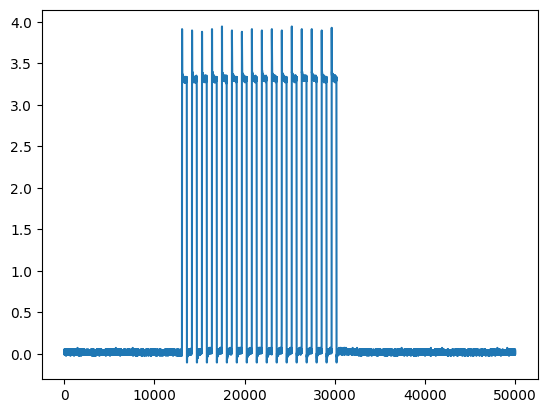

In [ ]:
import matplotlib.pyplot as plt
x=pd.read_csv(r"c:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_oscillo\Experience Mai 2023\WATER07_18MAI 2023\WATER07_RUN03", sep='\s+',skiprows=4, engine='python')
plt.plot(x["Y[3]"])
plt.show()


In [ ]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
# Dossiers racines à adapter
target_base  = r"C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_oscillo/Experience Mai 2023"
source_base = r"C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_fit"
def Temps_Pression(data_oscilo,Y="Y[3]"):
    data = pd.read_csv(data_oscilo, sep='\s+', skiprows=4, engine='python')
    temps, signale_spec =np.array(data['time']), np.array(data[Y])

    marche_spec=max(signale_spec)/2

    taille=len(signale_spec)
    delais=taille/10
    stop = False
    up = 0
    ti = 0
    t = []
    i=0
    while stop == False and i < taille: 
        s = 0
        if signale_spec[i] > marche_spec:
            ti = i
            up=0
            while signale_spec[i] > marche_spec:
                up += 1
                i += 1
                if i == taille: 
                    break
            t.append((temps[i]+temps[ti])/2 )
            i += up
            s = 0

        else:
            i += 1
            s += 1
        if s > delais or i == len(signale_spec):
            stop = True
            return t        


for folder_sample in os.listdir(source_base):
    print("data fit",folder_sample)
    for folder_run in os.listdir(os.path.join(source_base,folder_sample)):
        print("data fit",folder_run)
        Run=folder_run.upper()
        Sample=folder_sample.upper()
        for fold in os.listdir(target_base):
            if (Sample or folder_sample )in fold :
                #print(fold)
                for f in os.listdir(os.path.join(target_base,fold)):
                    if (Run or folder_run) in f:
                        try:
                            temps_list = Temps_Pression(os.path.join(os.path.join(target_base,fold),f))
                            output_path=os.path.join(os.path.join(os.path.join(source_base,folder_sample),folder_run),Sample+Run)
                            with open(output_path, 'w') as fout:
                                for t in temps_list:
                                    fout.write(str(t) + '\n')
                            print(f"Temps sauvegardés dans : {output_path}")
                        except Exception as e:
                            print(f"Erreur lors du traitement de {os.path.join(os.path.join(source_base,folder_sample),folder_run)} : {e}")
                            continue
                        
            




data fit Water07
data fit Run03
Temps sauvegardés dans : C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_fit\Water07\Run03\WATER07RUN03
data fit Run05
Temps sauvegardés dans : C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_fit\Water07\Run05\WATER07RUN05
data fit Water11
data fit RUN32
Temps sauvegardés dans : C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_fit\Water11\RUN32\WATER11RUN32
data fit Water12
data fit RUN13
Temps sauvegardés dans : C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_fit\Water12\RUN13\WATER12RUN13
data fit Water13
data fit RUN7
Temps sauvegardés dans : C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_fit\Water13\RUN7\WATER13RUN7
data fit Water15
data fit Run03
Temps sauvegardés dans : C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_fit\Water15\Run03\WATER15RUN03
data fit Run04
Temps sauvegardés dans : C:\Users\dembelef\Documents\Stage M2\ETUDE\Traitement\data_fit\Water15\Run04\WATER15RUN04
data fit

AttributeError: module 'ntpath' has no attribute 'listdir'